<a href="https://colab.research.google.com/github/m2nwo079/global-challenger-2026/blob/main/05_synthesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/globalchallenger'
plt.rcParams['savefig.dpi']  = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.unicode_minus'] = False

M = {}
for k in ['a', 'b', 'c']:
    p = f'{BASE}/output/module_{k}.json'
    with open(p) as f:
        M[k] = json.load(f)
    print(f'module_{k}.json  {os.path.getsize(p):>8,} bytes  keys={list(M[k])}')

Mounted at /content/drive
module_a.json    27,029 bytes  keys=['baselines', 'pooled_by_order', 'cohort_fits', 'trim_robustness', 'first_impression_by_length', 'continuation_hazard', 'cohort_curves', 'notes']
module_b.json   482,789 bytes  keys=['population', 'rule_totals_by_window', 'path_truncation', 'data_window_max_timestamp', 'campaign_credit_by_window', 'rank_agreement', 'rank_shift_vs_path_length', 'notes']
module_c.json     3,648 bytes  keys=['dataset', 'group_counts', 'itt', 'exposure_conditioning', 'late', 'paper_reproduction', 'notes']


In [ ]:
a_fit = pd.DataFrame(M['a']['cohort_fits'])
ex    = a_fit[a_fit.definition == 'n = K'].set_index('n')
pooled = pd.DataFrame(M['a']['pooled_by_order'])
c_itt  = pd.DataFrame(M['c']['itt']).set_index('outcome')
b_rank = pd.DataFrame(M['b']['rank_agreement'])
b_key  = b_rank[(b_rank.min_credit == 200) & (b_rank.window == 30)]

head = pd.DataFrame([
    ['A', 'Pooled CTR, first to last impression',
     f"{pooled.ctr.iloc[0]:.3f} -> {pooled.ctr.iloc[-1]:.3f}"],
    ['A', 'Fixed-length cohort CTR (n=5)',
     f"{ex.loc[5,'ctr_first']:.3f} -> {ex.loc[5,'ctr_last']:.3f}"],
    ['A', 'Decay coefficient range (n=3 to n=15)',
     f"{ex.loc[3,'alpha']:.3f} to {ex.loc[15,'alpha']:.3f}"],
    ['B', 'Share of path clicks observed',
     f"{M['b']['population']['observed_share_of_path_clicks']:.1%}"],
    ['B', 'Rank agreement, all_clicks vs last_click',
     f"Spearman {b_key[b_key.vs=='all_clicks'].spearman.iloc[0]:.3f}, "
     f"mean shift {b_key[b_key.vs=='all_clicks'].mean_shift.iloc[0]:.1f}"],
    ['C', 'ITT relative lift, conversions',
     f"{c_itt.loc['conversions','rel_lift']:.1%}"],
    ['C', 'Incremental share of treated conversions',
     f"{c_itt.loc['conversions','incremental_share']:.1%}"],
    ['C', 'Share of assigned users actually exposed',
     f"{M['c']['dataset']['exposure_rate_among_treated']:.1%}"],
], columns=['module', 'quantity', 'value'])

print(head.to_string(index=False))

module                                 quantity                           value
     A     Pooled CTR, first to last impression                  0.336 -> 0.705
     A            Fixed-length cohort CTR (n=5)                  0.510 -> 0.320
     A    Decay coefficient range (n=3 to n=15)                  0.423 to 0.082
     B            Share of path clicks observed                           79.0%
     B Rank agreement, all_clicks vs last_click Spearman 0.862, mean shift 17.6
     C           ITT relative lift, conversions                           59.4%
     C Incremental share of treated conversions                           37.3%
     C Share of assigned users actually exposed                            3.6%


In [ ]:
c_exp = pd.DataFrame(M['c']['exposure_conditioning']).set_index('grp')
p_e = c_exp.loc['exposed','conversions'] / c_exp.loc['exposed','n']
p_c = c_exp.loc['control','conversions'] / c_exp.loc['control','n']
naive_c = p_e / p_c - 1

par = pd.DataFrame({
    'Module A (observational)': [
        'Criteo display logs, 16.5M impressions',
        'Total sequence length n',
        'Bids are allocated on predicted response, so length reflects outcome',
        f"CTR rises {pooled.ctr.iloc[0]:.3f} to {pooled.ctr.iloc[-1]:.3f}",
        f"CTR falls within every fixed-length cohort",
        'Sign reversal; no causal coefficient identified',
    ],
    'Module C (randomised)': [
        'Criteo incrementality trial, 14.0M users',
        'Exposure',
        'Retargeting requires visiting inventory, so exposure reflects propensity',
        f"Conversion lift {naive_c:.0%} (exposed vs control)",
        f"Conversion lift {c_itt.loc['conversions','rel_lift']:.1%} (assignment)",
        f"{naive_c / c_itt.loc['conversions','rel_lift']:.0f}x inflation",
    ],
}, index=['Data', 'Post-treatment variable conditioned on',
          'Why it correlates with the outcome',
          'Result when conditioned on it',
          'Result when not conditioned on it',
          'Size of the error'])

pd.set_option('display.max_colwidth', 70)
print(par.to_string())

                                                                                    Module A (observational)                                                     Module C (randomised)
Data                                                                  Criteo display logs, 16.5M impressions                                  Criteo incrementality trial, 14.0M users
Post-treatment variable conditioned on                                               Total sequence length n                                                                  Exposure
Why it correlates with the outcome      Bids are allocated on predicted response, so length reflects outcome  Retargeting requires visiting inventory, so exposure reflects propensity
Result when conditioned on it                                                       CTR rises 0.336 to 0.705                                Conversion lift 2676% (exposed vs control)
Result when not conditioned on it                                 CTR falls within ev

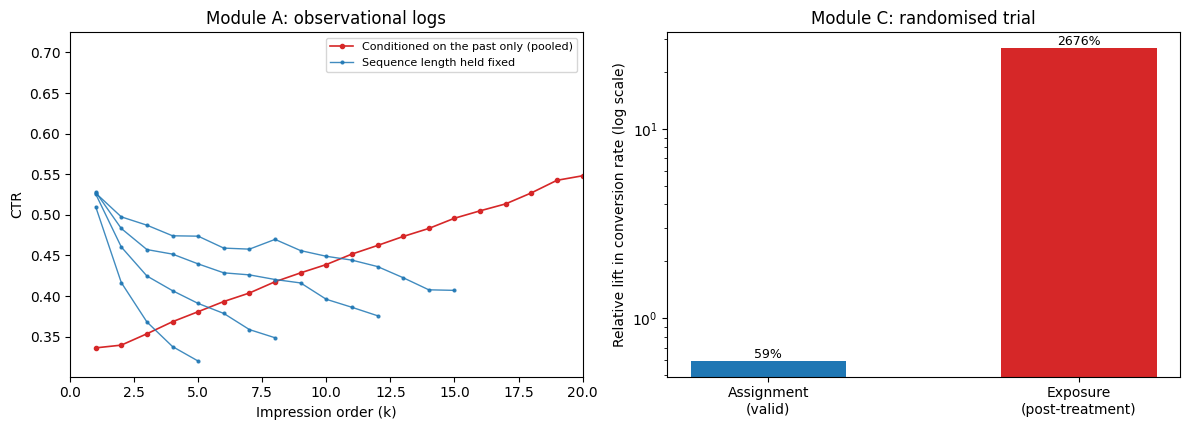

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))

m = pooled.impressions >= 5000
ax[0].plot(pooled.k[m], pooled.ctr[m], marker='o', ms=3, lw=1.2,
           color='tab:red', label='Conditioned on the past only (pooled)')
for K in [5, 8, 12, 15]:
    d = pd.DataFrame(M['a']['cohort_curves'][f'n={K}'])
    ax[0].plot(d.k, d.ctr, marker='.', ms=4, lw=1, alpha=0.85,
               color='tab:blue',
               label='Sequence length held fixed' if K == 5 else None)
ax[0].set(xlabel='Impression order (k)', ylabel='CTR', xlim=(0, 20),
          title='Module A: observational logs')
ax[0].legend(fontsize=8)

vals = [c_itt.loc['conversions','rel_lift'], naive_c]
bars = ax[1].bar(['Assignment\n(valid)', 'Exposure\n(post-treatment)'],
                 vals, 0.5, color=['tab:blue', 'tab:red'])
ax[1].set_yscale('log')
ax[1].set(ylabel='Relative lift in conversion rate (log scale)',
          title='Module C: randomised trial')
for b, v in zip(bars, vals):
    ax[1].text(b.get_x() + b.get_width()/2, v, f'{v:.0%}',
               ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{BASE}/figures/synthesis_conditioning.png')
plt.show()

In [ ]:
syn = {
    'headline': head.to_dict('records'),
    'parallel': par.to_dict(),
    'thesis': (
        'Measurement rules and conditioning choices determine the '
        'conclusion. Conditioning on a variable realised after treatment '
        'breaks the analysis in both observational and randomised data.'
    ),
    'module_outputs': ['module_a.json', 'module_b.json', 'module_c.json'],
}
with open(f'{BASE}/output/synthesis.json', 'w') as f:
    json.dump(syn, f, indent=2)
print('saved:', os.path.getsize(f'{BASE}/output/synthesis.json'), 'bytes')

saved: 2301 bytes
